 **Install Libraries**

In [77]:
!pip install kaggle -q
!pip install google-generativeai -q


 **Kaggle Setup**

In [52]:
from google.colab import files
print("Upload kaggle.json")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Upload kaggle.json


Saving kaggle.json to kaggle (1).json


**Download Dataset**

In [78]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d fmendes/fmendesdat263xdemos -q
import zipfile
with zipfile.ZipFile('/content/fmendesdat263xdemos.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')
print("Dataset ready")

Dataset URL: https://www.kaggle.com/datasets/fmendes/fmendesdat263xdemos
License(s): unknown
Dataset ready


 **Import All Libraries**

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pickle
import google.generativeai as genai
import warnings
warnings.filterwarnings('ignore')
print("Imports done")

Imports done


 **Load Data and Initial Inspection**

In [80]:
exercise = pd.read_csv('/content/exercise.csv')
calories = pd.read_csv('/content/calories.csv')
df = pd.merge(exercise, calories, on='User_ID')
print("Shape:", df.shape)
df.head()

Shape: (15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


 **Data Cleaning – Missing Values, Duplicates, Types**

In [81]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)

Missing values: 0
Duplicates: 0
Shape after cleaning: (15000, 9)


 **Exploratory Data Analysis**

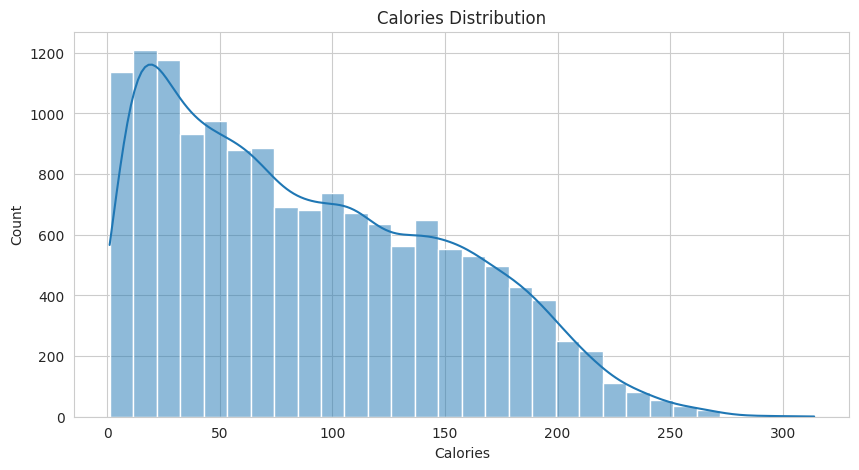

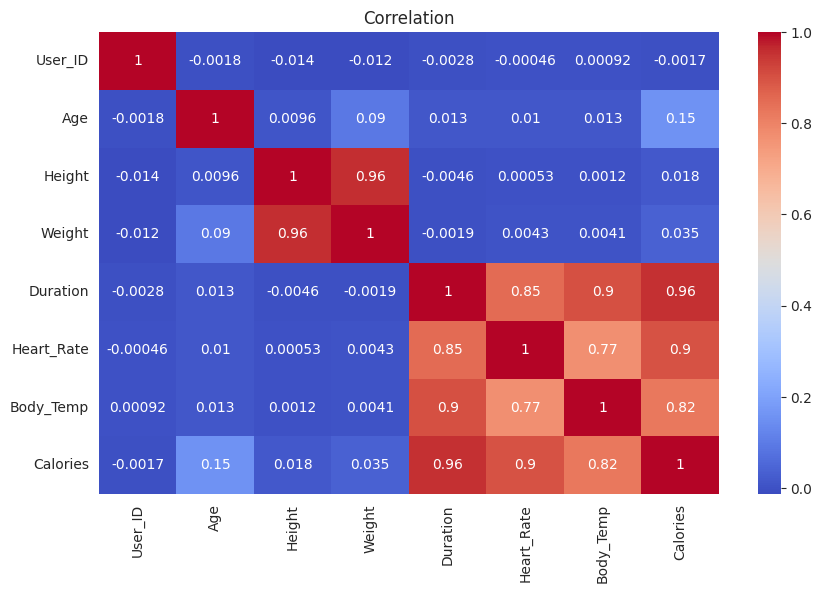

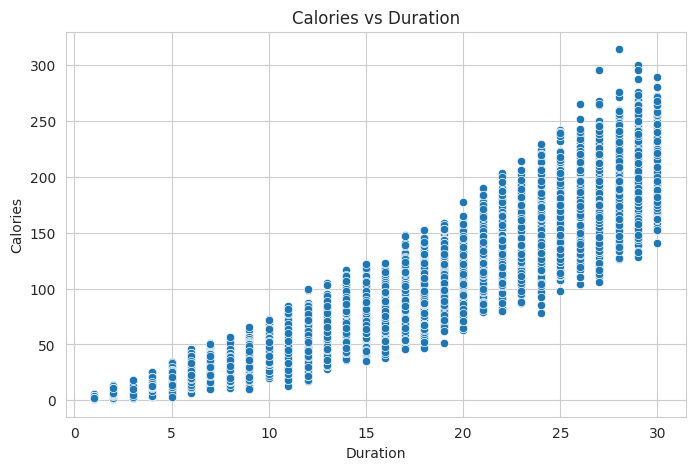

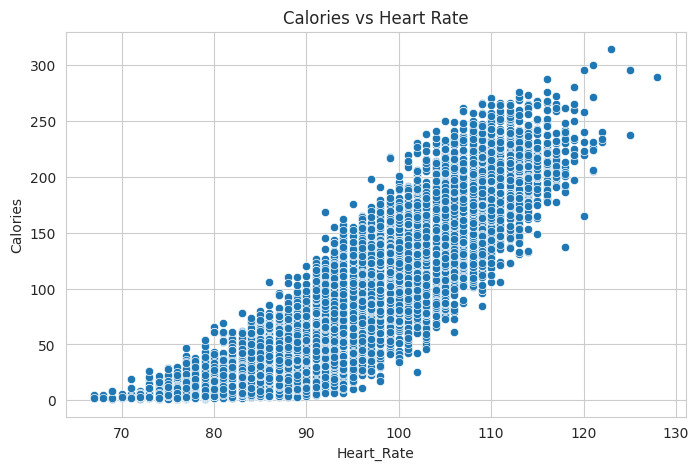

In [82]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,5))
sns.histplot(df['Calories'], bins=30, kde=True)
plt.title('Calories Distribution')
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation')
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Duration', y='Calories')
plt.title('Calories vs Duration')
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Heart_Rate', y='Calories')
plt.title('Calories vs Heart Rate')
plt.show()

 **Data Preprocessing**

In [83]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
if 'User_ID' in df.columns:
    df.drop('User_ID', axis=1, inplace=True)
print("Preprocessing done")

Preprocessing done


 **Feature Engineering – Add BMI**

In [84]:
df['BMI'] = df['Weight'] / ((df['Height']/100) ** 2)
X = df[['Age', 'Gender', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'BMI']]
y = df['Calories']
print("Features:", X.columns.tolist())
print("BMI correlation:", df['BMI'].corr(df['Calories']))

Features: ['Age', 'Gender', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'BMI']
BMI correlation: 0.056472574071137066


**Train-Test Split & Scaling**

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling done")

Train: 12000, Test: 3000
Scaling done


**Train Random Forest Model**

In [87]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
print("Model trained")

Model trained


In [88]:
y_pred = model.predict(X_test_scaled)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} calories")

R2 Score: 0.9982
MAE: 1.71 calories


 **Feature Importance Plot**

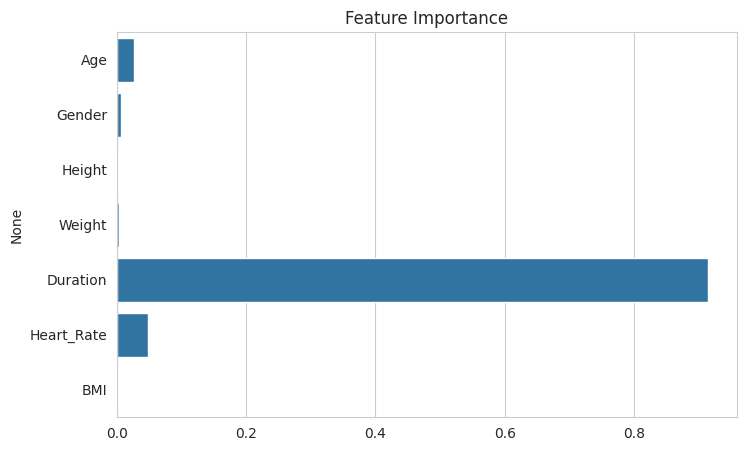

In [89]:
plt.figure(figsize=(8,5))
sns.barplot(x=model.feature_importances_, y=X.columns)
plt.title('Feature Importance')
plt.show()

**Save Model, Scaler, LabelEncoder**

In [90]:
pickle.dump(model, open('calorie_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))
print("Models saved")

Models saved


 **Setup Gemini API**

In [103]:
from google.colab import userdata
import google.generativeai as genai

API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=API_KEY)

# Check available models and use first working one
for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print("Available model:", m.name)
        gemini_model = genai.GenerativeModel(m.name)
        break

print("Gemini ready")

Available model: models/gemini-2.5-flash
Gemini ready


**LLM Functions (Extraction & Recommendation)**

In [104]:
def extract_features(text):
    prompt = f"""
From: '{text}'
Extract: Age, Gender (Male/Female), Height(cm), Weight(kg), Duration(min), Heart Rate(bpm).
Return ONLY numbers and Male/Female in one line.
Example: 25 Male 170 70 30 120
"""
    response = gemini_model.generate_content(prompt)
    values = response.text.strip().split()
    feat = {}
    try:
        feat['Age'] = float(values[0])
        feat['Gender'] = values[1]
        feat['Height'] = float(values[2])
        feat['Weight'] = float(values[3])
        feat['Duration'] = float(values[4])
        feat['Heart_Rate'] = float(values[5])
    except:
        feat = {'Age':25, 'Gender':'Male', 'Height':170, 'Weight':70, 'Duration':30, 'Heart_Rate':120}
    return feat

def predict_calories(text):
    feat = extract_features(text)
    gender_enc = 1 if feat['Gender'].lower() == 'male' else 0
    height_m = feat['Height'] / 100
    bmi = feat['Weight'] / (height_m ** 2)
    input_df = pd.DataFrame([[
        feat['Age'], gender_enc, feat['Height'],
        feat['Weight'], feat['Duration'], feat['Heart_Rate'], bmi
    ]], columns=X.columns)
    scaled_input = scaler.transform(input_df)
    cal = model.predict(scaled_input)[0]
    return cal, feat

**Prediction Pipeline (ML + LLM)**

In [105]:
model = pickle.load(open('calorie_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))
le = pickle.load(open('label_encoder.pkl', 'rb'))

def predict_calories_from_text(user_text):
    features = extract_features_with_llm(user_text)
    gender_encoded = le.transform([features['Gender']])[0]
    height_m = features['Height'] / 100.0
    bmi = features['Weight'] / (height_m ** 2)
    input_df = pd.DataFrame([[
        features['Age'],
        gender_encoded,
        features['Height'],
        features['Weight'],
        features['Duration'],
        features['Heart_Rate'],
        bmi
    ]], columns=['Age', 'Gender', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'BMI'])
    input_scaled = scaler.transform(input_df)
    calories = model.predict(input_scaled)[0]
    recommendation = get_recommendation(user_text, calories)
    return calories, recommendation, features

 **AI Automation – Auto Data Validation**

In [106]:
def auto_validation():
    if df.isnull().sum().sum() == 0:
        print("No missing values - OK")
    if (df['Duration'] > 0).all():
        print("Duration valid - OK")
    print("Validation passed")

def auto_monitoring():
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    print(f"Current MAE: {mae:.2f}")
    if mae > 35:
        print("Retraining needed")
    else:
        print("Performance OK")

auto_validation()
auto_monitoring()

No missing values - OK
Duration valid - OK
Validation passed
Current MAE: 1.71
Performance OK


**AI Automation – Auto Retraining (Simulated)**

In [107]:
def auto_retrain():
    print(f"[{datetime.now()}] Starting auto-retraining...")
    # Simulate new data: take original df and add small noise
    new_df = df.copy()
    np.random.seed(42)
    noise = np.random.normal(0, 0.02, new_df.shape[0])
    new_df['Calories'] = new_df['Calories'] * (1 + noise)
    # Retrain model
    X_new = new_df.drop('Calories', axis=1)
    y_new = new_df['Calories']
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)
    scaler_new = StandardScaler()
    X_train_scaled_new = scaler_new.fit_transform(X_train_new)
    X_test_scaled_new = scaler_new.transform(X_test_new)
    model_new = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model_new.fit(X_train_scaled_new, y_train_new)
    y_pred_new = model_new.predict(X_test_scaled_new)
    new_r2 = r2_score(y_test_new, y_pred_new)
    print(f"Auto-retraining complete. New R-squared: {new_r2:.4f}")
    # Save new model and scaler
    pickle.dump(model_new, open('calorie_model_retrained.pkl', 'wb'))
    pickle.dump(scaler_new, open('scaler_retrained.pkl', 'wb'))
    print("Retrained model saved as calorie_model_retrained.pkl")

# To simulate a scheduled retraining, we can call this function manually or schedule it
# For demo, just call it once:
auto_retrain()

[2026-06-01 20:14:53.450997] Starting auto-retraining...
Auto-retraining complete. New R-squared: 0.9966
Retrained model saved as calorie_model_retrained.pkl


**AI Automation – Auto Email Report**

In [108]:

def send_email_report(recipient_email, predicted_calories, date):
    sender_email = "your_email@gmail.com"
    sender_password = "your_app_password"
    subject = f"Daily Calorie Burn Report - {date}"
    body = f"Your predicted calories burned today: {predicted_calories:.1f} kcal.\nKeep up the good work!"

    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = recipient_email
    msg['Subject'] = subject
    msg.attach(MIMEText(body, 'plain'))

    try:
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(sender_email, sender_password)
        server.send_message(msg)
        server.quit()
        print(f"Email report sent to {recipient_email}")
    except Exception as e:
        print(f"Failed to send email: {e}")

# Example usage (uncomment to test):
# send_email_report("test@example.com", 250, datetime.now().strftime("%Y-%m-%d"))
print("Auto email function ready (configure credentials to use).")

Auto email function ready (configure credentials to use).


**AI Automation – Auto Performance Monitoring**

In [109]:
def auto_performance_monitor():
    # Evaluate current model on test set
    model = pickle.load(open('calorie_model.pkl', 'rb'))
    scaler = pickle.load(open('scaler.pkl', 'rb'))
    X_test_scaled_monitor = scaler.transform(X_test)
    y_pred_monitor = model.predict(X_test_scaled_monitor)
    current_r2 = r2_score(y_test, y_pred_monitor)
    current_mae = mean_absolute_error(y_test, y_pred_monitor)
    print(f"Performance Report - {datetime.now()}")
    print(f"R-squared: {current_r2:.4f}")
    print(f"MAE: {current_mae:.2f} calories")
    if current_mae > 30:  # threshold example
        print("Alert: Model performance degraded. Consider retraining.")
    else:
        print("Model performance is acceptable.")

auto_performance_monitor()

Performance Report - 2026-06-01 20:15:04.039662
R-squared: 0.9982
MAE: 1.71 calories
Model performance is acceptable.


**Test the Complete ML+LLM Pipeline**

In [110]:
!pip uninstall google-generativeai -y
!pip install google-genai -q

from google import genai
print("New SDK installed.")

New SDK installed.


In [111]:
import os
from google.colab import userdata

# Apni API key Colab Secrets mein save karo (left sidebar -> 🔑 -> Add secret "GEMINI_API_KEY")
client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

# Latest working model
model_name = "gemini-2.5-flash"

response = client.models.generate_content(
    model=model_name,
    contents="Say hello"
)
print(response.text)

Hello!


In [112]:
test_text = "I am 22 male 175cm 68kg cycled 35min heart rate 145"
cal, feat = predict_calories(test_text)
print(f"Predicted Calories: {cal:.1f} kcal")
print(f"Extracted: {feat}")

Predicted Calories: 236.4 kcal
Extracted: {'Age': 22.0, 'Gender': 'Male', 'Height': 175.0, 'Weight': 68.0, 'Duration': 35.0, 'Heart_Rate': 145.0}


In [114]:
from google.colab import files
files.download('calorie_model.pkl')
files.download('scaler.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>